# RAIL photo-z estimates for Rubin Early Data Preview 2 (EDP2)

In this tutorial, we will:
- access a photo-z catalog derived from Rubin’s Data Preview 2 using LSDB

## 1. Loading through LSDB

In order to access the catalog through LSDB, you must be a [Rubin data rights holder](https://rubinobservatory.org/for-scientists/data-products/data-policy), because the catalog includes sky coordinates from the original DP2 dataset. Please see [Accessing Rubin Data Preview 2 (DP2)](./rubin_dp2.ipynb) for the data access instructions.

In [1]:
import lsdb
import os
import matplotlib.pyplot as plt
from dask.distributed import Client
from upath import UPath

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

# Replace with the actual path if not at RSP
base_path = UPath("/rubin/lsdb_data")
catalog_path = base_path / "object_photoz"
dp2_pz_catalog = lsdb.open_catalog(catalog_path)
dp2_pz_catalog

,objectId,ra,dec,bpz_z_best,dnf_z_best,fzboost_z_best,gpz_z_best,knn_z_best,tpz_z_best
npartitions=1356,,,,,,,,,
"Order: 3, Pixel: 265",int64[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow]
...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3070",...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 49136",...,...,...,...,...,...,...,...,...


In [2]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

### Plotting two estimators

As an example, let us plot the results from TPZ and kNN.
We load just two columns and select COSMOS field by a cone search.

In [ ]:
dp2_pz_catalog_small = lsdb.open_catalog(
    catalog_path,
    columns=["tpz_z_best", "knn_z_best"],
    search_filter=lsdb.ConeSearch(ra=150.11, dec=2.23, radius_arcsec=1.0 * 3600.0),
)

with Client(
    n_workers=2,
    threads_per_worker=1,
    memory_limit="8GB",
    local_directory=f"/deleted-sundays/{os.environ.get('USER', 'dask_scratch')}",
) as client:
    print(f"Dask dashboard: {client.dashboard_link}")
    display(client)
    df = dp2_pz_catalog_small.compute()

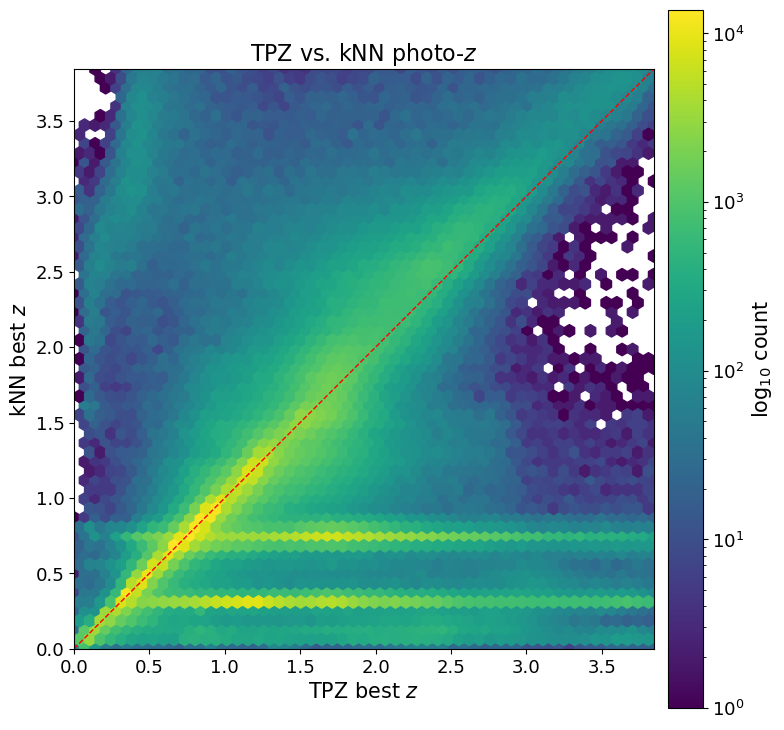

In [6]:
import numpy as np

zmax = max(0.5, float(np.nanpercentile(np.concatenate([df["tpz_z_best"], df["knn_z_best"]]), 99.0)))

fig, ax = plt.subplots(figsize=(8, 7.5))
hb = ax.hexbin(
    df["tpz_z_best"],
    df["knn_z_best"],
    gridsize=55,
    bins="log",
    extent=(0, zmax, 0, zmax),
    mincnt=1,
    cmap="viridis",
)
ax.plot([0, zmax], [0, zmax], "r--", lw=1)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("log$_{10}$ count")
ax.set_xlim(0, zmax)
ax.set_ylim(0, zmax)
ax.set_aspect("equal")
ax.set_xlabel("TPZ best $z$")
ax.set_ylabel("kNN best $z$")
ax.set_title("TPZ vs. kNN photo-$z$")

fig.tight_layout()
plt.show()

## About

**Authors**: Sandro Campos, Sarah Pelesky, Tianqing Zhang, Konstantin Malanchev

**Last run**: N/A

If you use `lsdb` for published research, please cite following [instructions](https://docs.lsdb.io/en/stable/citation.html).